# Data preparation

Dataset: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce/data


## Objectives

This is the initial stage of the project, where I examine the provided data, check for potential issues, and build an order-level dataset in CSV format that can be used in Tableau Public for an Overview dashboard.

- read and familiarize myself with the dataset description on Kaggle
- import datasets
- check for null values and inconsistencies
- combine datasets into a single order-level dataset and save it as a CSV file

## Data import and exploration

Olist provides 9 CSV files with data, all stored in the dataset folder.  
They are imported using the pandas `read_csv` function and inspected using `display()` and `DataFrame.info()` to get an initial overview.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
customers_ds = pd.read_csv('dataset/olist_customers_dataset.csv')
geolocation_ds = pd.read_csv('dataset/olist_geolocation_dataset.csv')
order_items_ds = pd.read_csv('dataset/olist_order_items_dataset.csv')
order_payments_ds = pd.read_csv('dataset/olist_order_payments_dataset.csv')
order_reviews_ds = pd.read_csv('dataset/olist_order_reviews_dataset.csv')
orders_ds = pd.read_csv('dataset/olist_orders_dataset.csv')
products_ds = pd.read_csv('dataset/olist_products_dataset.csv')
sellers_ds = pd.read_csv('dataset/olist_sellers_dataset.csv')
product_category_name_translation_ds = pd.read_csv('dataset/product_category_name_translation.csv')

In [3]:
print("customers_ds")
display(customers_ds.head())
customers_ds.info()

customers_ds


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


### Note: Unique customers

It looks like there are two different customer IDs: one unique identifier and another one specific to each order.  
When calculating active users and new users, I need to use `customer_unique_id`.

Below is the number of unique customers compared to all customer IDs:

In [4]:
print(customers_ds['customer_id'].nunique(), customers_ds['customer_unique_id'].nunique())

99441 96096


In [5]:
# item freight value item (if an order has more than one item the freight value is splitted between items)
print("order_items_ds")
display(order_items_ds.head())
order_items_ds.info()

order_items_ds


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB


### Note: Payment calculation

Each item has both `price` and `freight_value`.  
When looking at the `order_payments` dataset, the `payment_value` appears to be approximately equal to the sum of item `price` and `freight_value` for the order.

Here is an example:

In [6]:
order_items_ds[order_items_ds['order_id'] == "00042b26cf59d7ce69dfabb4e55b4fd9"]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.9,18.14


In [7]:
order_payments_ds[order_payments_ds['order_id'] == "00042b26cf59d7ce69dfabb4e55b4fd9"]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
98711,00042b26cf59d7ce69dfabb4e55b4fd9,1,credit_card,3,218.04


In [8]:
print("order_payments_ds")
display(order_payments_ds.head())
order_payments_ds.info()

order_payments_ds


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.0 MB


### Note: Multiple payments per order

Some orders have multiple payments, which must be aggregated when calculating the total payment value.

Below are examples showing how many payments there can be per order and the data for one such order. I also verified that the sum of payments matches the sum of item prices plus freight values for this order.

In [9]:
order_payments_ds['order_id'].nunique()

99440

In [10]:
order_payments_ds.groupby('order_id')['order_id'] \
    .count() \
    .reset_index(name='count') \
    .sort_values(['count'], ascending=False) \
    .head(5)

,order_id,count
97261,fa65dad1b0e818e3ccc5cb0e39231352,29
79611,ccf804e764ed5650cd8759557269dc13,26
15577,285c2e15bebd4ac83635ccc563dc71f4,22
53168,895ab968e7bb0d5659d16cd74cd1650c,21
99020,fedcd9f7ccdc8cba3a18defedd1a5547,19


In [11]:
order_payments_ds[order_payments_ds['order_id'] == 'fedcd9f7ccdc8cba3a18defedd1a5547'].sort_values(['payment_sequential'])

,order_id,payment_sequential,payment_type,payment_installments,payment_value
9665,fedcd9f7ccdc8cba3a18defedd1a5547,1,credit_card,1,1.67
27087,fedcd9f7ccdc8cba3a18defedd1a5547,2,voucher,1,7.76
87783,fedcd9f7ccdc8cba3a18defedd1a5547,3,voucher,1,26.94
45197,fedcd9f7ccdc8cba3a18defedd1a5547,4,voucher,1,10.33
36869,fedcd9f7ccdc8cba3a18defedd1a5547,5,voucher,1,9.76
103569,fedcd9f7ccdc8cba3a18defedd1a5547,6,voucher,1,8.60
95493,fedcd9f7ccdc8cba3a18defedd1a5547,7,voucher,1,11.78
15930,fedcd9f7ccdc8cba3a18defedd1a5547,8,voucher,1,31.43
14352,fedcd9f7ccdc8cba3a18defedd1a5547,9,voucher,1,5.30
44641,fedcd9f7ccdc8cba3a18defedd1a5547,10,voucher,1,13.27


In [12]:
print("paid: {}".format(order_payments_ds[order_payments_ds['order_id'] == 'fedcd9f7ccdc8cba3a18defedd1a5547']['payment_value'].sum()))
print("price: {}".format(order_items_ds[order_items_ds['order_id'] == 'fedcd9f7ccdc8cba3a18defedd1a5547']['price'].sum()))
print("freight: {}".format(order_items_ds[order_items_ds['order_id'] == 'fedcd9f7ccdc8cba3a18defedd1a5547']['freight_value'].sum()))

paid: 205.74
price: 159.98
freight: 45.76


In [13]:
order_items_ds[order_items_ds['order_id'] == 'fedcd9f7ccdc8cba3a18defedd1a5547']

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
112173,fedcd9f7ccdc8cba3a18defedd1a5547,1,0554911df28fda9fd668ce5ba5949695,7c67e1448b00f6e969d365cea6b010ab,2017-10-05 17:44:41,79.99,22.88
112174,fedcd9f7ccdc8cba3a18defedd1a5547,2,0554911df28fda9fd668ce5ba5949695,7c67e1448b00f6e969d365cea6b010ab,2017-10-05 17:44:41,79.99,22.88


In [14]:
print("orders_ds")
display(orders_ds.head())
orders_ds.info()

orders_ds


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


### Note: Order status

Since most orders have the status `delivered`, and orders with other statuses might have incomplete payment data, I will only use delivered orders for this project.

In real-world analysis, this depends on the purpose of the dashboard and may include either realized revenue or the full booked amount.

In [15]:
orders_ds.groupby('order_status')['order_status'].count().reset_index(name='count').sort_values(['count'], ascending=False)

,order_status,count
3,delivered,96478
6,shipped,1107
1,canceled,625
7,unavailable,609
4,invoiced,314
5,processing,301
2,created,5
0,approved,2


## Data validation

`DataFrame.info()` showed no null values in the important fields.  
Next, I perform a quick check for duplicates and incorrect prices.

In [16]:
print("duplicates in orders_ds: {}".format(orders_ds['order_id'].duplicated().sum()))
print("duplicates in order_payments_ds: {}".format(order_payments_ds.duplicated().sum()))
print("duplicates in order_items_ds: {}".format(order_items_ds.duplicated().sum()))

print("incorrect price in order_items_ds: {}".format(order_items_ds[order_items_ds['price'] <= 0]['price'].count()))

duplicates in orders_ds: 0
duplicates in order_payments_ds: 0
duplicates in order_items_ds: 0
incorrect price in order_items_ds: 0


### Price validation

There are no negative prices, but it is still worth checking the price distribution for anomalies.  
I do this by plotting a histogram of prices.

The data appears logical: higher-priced items are purchased less frequently.

<Axes: ylabel='Frequency'>

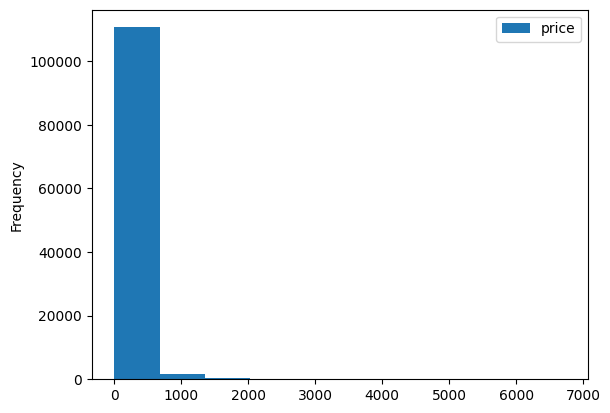

In [17]:
order_items_ds.plot.hist(column='price')

<Axes: ylabel='Frequency'>

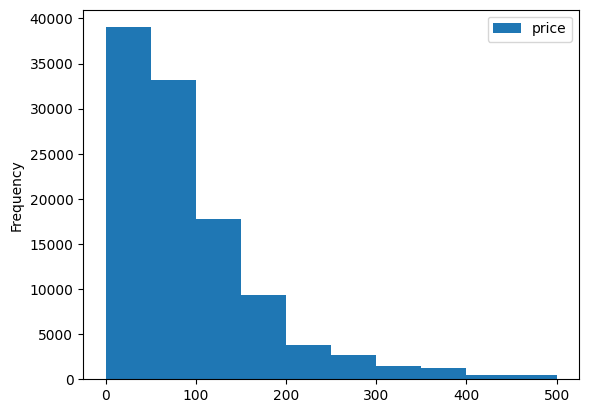

In [18]:
# And closer look at a smaller range
order_items_ds.plot.hist(column='price', range = (0, 500))

### Expensive categories

To ensure that items with large prices are not in a different currency or affected by data errors, I check their categories.

The data does not show any anomalies here either.

In [19]:
# joining order_items with products and product_category_name_translation
expensive_items_ds = order_items_ds[order_items_ds.price > 2000][['product_id', 'price']].merge(
    products_ds[['product_id', 'product_category_name']], on='product_id').merge(
        product_category_name_translation_ds[['product_category_name', 'product_category_name_english']], on='product_category_name')
expensive_items_ds['product_category_name_english'].unique()

<StringArray>
[                'computers_accessories',
                            'housewares',
                     'home_appliances_2',
                          'garden_tools',
                             'computers',
       'construction_tools_construction',
                      'small_appliances',
                            'cool_stuff',
                         'watches_gifts',
             'construction_tools_safety',
                        'sports_leisure',
                           'electronics',
 'small_appliances_home_oven_and_coffee',
                                  'baby',
                   'musical_instruments',
        'industry_commerce_and_business',
                             'telephony',
                         'health_beauty',
                                  'auto',
                        'consoles_games',
                       'home_appliances',
            'agro_industry_and_commerce',
                              'pet_shop',
                    

## Order-level dataset

Everything looks correct, so I now create an order-level dataset for the Overview dashboard.

For the top-level dashboard, I will need the following key metrics:

- GMV — total amount paid (it's realized GMV — includes only delivered orders)
- Orders — number of orders
- AOV — average order value
- Active customers — number of users placing orders
- Freight share (%)
- New users share (%)

In [20]:
# filtering only orders in 'delivered' status,
#   merging it with customers to get unique customer ids,
#   and with order_payments, already aggregated by order_id to not duplicate payments,
#   and with order_items to calculate freight value of the order
orders_with_prices = orders_ds[['order_id', 'customer_id', 'order_purchase_timestamp', 'order_status']] \
    [orders_ds['order_status'] == 'delivered'] \
    .merge(customers_ds[['customer_id', 'customer_unique_id']], on='customer_id', how='left') \
    .merge(order_payments_ds[['order_id', 'payment_value']].groupby('order_id').sum(), on='order_id', how='left') \
    .merge(order_items_ds[['order_id', 'price', 'freight_value']].groupby('order_id').sum(), on='order_id', how='left')
display(orders_with_prices.info())
orders_with_prices.head()

<class 'pandas.DataFrame'>
RangeIndex: 96478 entries, 0 to 96477
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   order_id                  96478 non-null  str    
 1   customer_id               96478 non-null  str    
 2   order_purchase_timestamp  96478 non-null  str    
 3   order_status              96478 non-null  str    
 4   customer_unique_id        96478 non-null  str    
 5   payment_value             96477 non-null  float64
 6   price                     96478 non-null  float64
 7   freight_value             96478 non-null  float64
dtypes: float64(3), str(5)
memory usage: 5.9 MB


None

,order_id,customer_id,order_purchase_timestamp,order_status,customer_unique_id,payment_value,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,delivered,7c396fd4830fd04220f754e42b4e5bff,38.71,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,delivered,af07308b275d755c9edb36a90c618231,141.46,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,delivered,3a653a41f6f9fc3d2a113cf8398680e8,179.12,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,delivered,7c142cf63193a1473d2e66489a9ae977,72.20,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,delivered,72632f0f9dd73dfee390c9b22eb56dd6,28.62,19.90,8.72


### Data validation after join

After joining the datasets, one order has missing information:

Order `bfbd0f9bdef84302105ad712db648a6c` has no payment data, but it does have `price` and `freight_value` and is already delivered.

It is safe to exclude it from the dashboard.

In real life, it would be a good idea to create a ticket for data engineers or developers to investigate, especially if the price is large or if there are many such cases.

In [21]:
orders_with_prices[orders_with_prices['payment_value'].isna()]

,order_id,customer_id,order_purchase_timestamp,order_status,customer_unique_id,payment_value,price,freight_value
29811,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,2016-09-15 12:16:38,delivered,830d5b7aaa3b6f1e9ad63703bec97d23,NaN,134.97,8.49


In [22]:
orders_with_prices = orders_with_prices.dropna()

### Additional calculated fields

To identify new customers, I add a field called `order_num`, which shows the sequence number of the order for each customer in ascending order by date.

In [23]:
orders_with_prices['order_num'] = orders_with_prices.sort_values(['customer_unique_id','order_purchase_timestamp'], ascending=[True,True]) \
             .groupby(['customer_unique_id']) \
             .cumcount() + 1
orders_with_prices

,order_id,customer_id,order_purchase_timestamp,order_status,customer_unique_id,payment_value,price,freight_value,order_num
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,delivered,7c396fd4830fd04220f754e42b4e5bff,38.71,29.99,8.72,2
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,delivered,af07308b275d755c9edb36a90c618231,141.46,118.70,22.76,1
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,delivered,3a653a41f6f9fc3d2a113cf8398680e8,179.12,159.90,19.22,1
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,delivered,7c142cf63193a1473d2e66489a9ae977,72.20,45.00,27.20,1
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,delivered,72632f0f9dd73dfee390c9b22eb56dd6,28.62,19.90,8.72,1
...,...,...,...,...,...,...,...,...,...
96473,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,2017-03-09 09:54:05,delivered,6359f309b166b0196dbf7ad2ac62bb5a,85.08,72.00,13.08,1
96474,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,2018-02-06 12:58:58,delivered,da62f9e57a76d978d02ab5362c509660,195.00,174.90,20.10,1
96475,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,2017-08-27 14:46:43,delivered,737520a9aad80b3fbbdad19b66b37b30,271.01,205.99,65.02,1
96476,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,2018-01-08 21:28:27,delivered,5097a5312c8b157bb7be58ae360ef43c,441.16,359.98,81.18,1


### Check customers with many orders

To verify that the calculation works correctly, I list customers with many orders and show an example of one of them.

In [24]:
orders_with_prices.groupby(['customer_unique_id'])['customer_unique_id'].count().reset_index(name='count').sort_values(['count'], ascending=False)

,customer_unique_id,count
51430,8d50f5eadf50201ccdcedfb9e2ac8455,15
22779,3e43e6105506432c953e165fb2acf44c,9
73920,ca77025e7201e3b30c44b472ff346268,7
10060,1b6c7548a2a1f9037c1fd3ddfed95f33,7
36706,6469f99c1f9dfae7733b25662e7f1782,7
...,...,...
93337,ffeefd086fc667aaf6595c8fe3d22d54,1
46676,7fc4fe288bb0f156a1915c094c9dc358,1
93339,fff1afc79f6b5db1e235a4a6c30ceda7,1
46677,7fc5f80feaa9ec1ed5eca61ae1442c18,1


In [25]:
orders_with_prices[orders_with_prices['customer_unique_id'] == 'ca77025e7201e3b30c44b472ff346268'].sort_values(['order_purchase_timestamp'])

,order_id,customer_id,order_purchase_timestamp,order_status,customer_unique_id,payment_value,price,freight_value,order_num
83738,ee84d18908ccf2b4c57008c552b98d1c,fc709ab645b71acd6046aeb03b590aa5,2017-10-09 12:34:39,delivered,ca77025e7201e3b30c44b472ff346268,289.07,269.90,19.17,1
57860,f3584b023b097595c8e2b0b6fd51a839,c59e684f832f832056ceee2c310cfc7f,2018-01-25 21:10:57,delivered,ca77025e7201e3b30c44b472ff346268,78.86,59.90,18.96,2
79367,c70e1bd940c5723bf066a1dbcc1455e8,b145bff18e79ac4dfb3fb91e61906f38,2018-02-09 15:43:37,delivered,ca77025e7201e3b30c44b472ff346268,159.23,125.90,33.33,3
5147,9e22fb4a47d29059ef9689ca8b26d8b3,dc7dc47999d1b3c4c2f6a085a1a76eef,2018-02-17 01:22:20,delivered,ca77025e7201e3b30c44b472ff346268,213.68,156.97,56.71,4
24586,d07179898f582cd4b62f9f5328698baf,71f39c371308d132d7633895477dd307,2018-04-26 11:44:48,delivered,ca77025e7201e3b30c44b472ff346268,95.56,74.99,20.57,5
26713,cc9782f02aae34f01d12f3dbee4d5d93,852e5ea6e9d74416ddf88bdbdb3189b9,2018-05-03 06:11:22,delivered,ca77025e7201e3b30c44b472ff346268,192.12,43.96,148.16,6
9850,8dacd1da7c4dc40d5c59e7ddd93b3ac8,6ccedfba5919d72fcc8c51bfa982de62,2018-06-01 11:38:29,delivered,ca77025e7201e3b30c44b472ff346268,94.20,74.99,19.21,7


### Combined data price validation

I want to check whether prices look valid after joining the tables.  
I expect `payment_value` to be approximately equal to `price + freight_value`.

This is not always exactly true: some orders have differences of up to 181. However, this affects no more than 0.3% of all orders, and the difference is always a small share of the total order price.

I assume this may be due to rounding, bank processing fees, installment payments, or similar factors.

For GMV, I will use `payment_value` as the most accurate representation of how much money the marketplace processed.

In real-life analysis, the exact definition may depend on the dashboard purpose and should be confirmed with stakeholders.

In [26]:
orders_with_prices['price_diff'] = orders_with_prices['price'] + orders_with_prices['freight_value'] - orders_with_prices['payment_value']
orders_with_prices.sort_values(by='price_diff')

,order_id,customer_id,order_purchase_timestamp,order_status,customer_unique_id,payment_value,price,freight_value,order_num,price_diff
11458,ce6d150fb29ada17d2082f4847107665,d8acb46c718975948423dbf1b603b959,2018-01-25 11:17:02,delivered,3629a4b18f2eb69e03f153158e48d2cc,1586.47,1299.00,104.66,1,-182.81
47235,6e5fe7366a2e1bfbf3257dba0af1267f,5263febf1413e9a60ceb7b842008b7ef,2016-10-09 22:36:25,delivered,6f90ec5150be36c4475835b5941ab56f,406.92,179.19,108.72,1,-119.01
68752,70b742795bc441e94a44a084b6d9ce7a,0c155574f4f4d27594dbdd37731a6ecb,2017-08-24 10:29:36,delivered,b8b3c435a58aebd788a477bed8342910,578.82,269.99,196.94,3,-111.89
32174,996c7e73600ad3723e8627ab7bef81e4,16be3ab0d37467d1f96d6fc30613ee57,2018-07-16 09:58:16,delivered,99567d452c6589499a2ba8b0fd4658e5,664.43,559.90,28.00,1,-76.53
51423,70b7e94ea46d3e8b5bc12a50186edaf0,1c4c6fd6cfc21396ae93680bfc5c34d4,2018-01-01 13:06:57,delivered,8bd9c53ae5e194fd363ed6714235e6be,274.84,167.88,45.27,1,-61.69
...,...,...,...,...,...,...,...,...,...,...
59716,6dcf0aeb8b1eb4021c26e1d0e9394979,8d10ccfe7c979ef982e4964bbff62637,2018-08-09 20:37:34,delivered,8d43f7b8f33f60fb6ae5ec21072135b5,318.97,299.00,34.92,1,14.95
34560,4154bf1348caac78152fe76e3e9c4af8,90ce0548c953a250526eac9fbc2c2951,2018-08-23 20:34:07,delivered,60ef1068bcbffaed11615482aeb7c8bf,150.27,149.90,15.36,1,14.99
1932,6e57e23ecac1ae881286657694444267,2dda54e25d0984e12705c84d4030e6e0,2018-08-09 17:36:47,delivered,71692b73230707ce0f95d8a6091c22b4,333.91,330.00,20.41,1,16.50
44249,fd33085945f15975375cd8ec85440511,8071c6018a4f75f2afd849a34708e3a0,2018-08-20 19:34:29,delivered,d0b614ed8a43dca2f98a7c093723809d,212.82,217.99,16.63,1,21.80


In [27]:
small_price_diff = orders_with_prices[abs(orders_with_prices['price_diff']) < 0.01]['price_diff'].count()
order_cnt = orders_with_prices['price_diff'].count()
print("price diff less than 0.01: {}".format(small_price_diff))
print("total orders: {}".format(order_cnt))
print("share of all orders: {:.2f}%".format(small_price_diff/order_cnt * 100))
print("max diff: {:.2f}".format(orders_with_prices['price_diff'].max()))
print("min diff: {:.2f}".format(orders_with_prices['price_diff'].min()))

price diff less than 0.01: 96102
total orders: 96477
share of all orders: 99.61%
max diff: 51.62
min diff: -182.81


## Final dataset and output to file

### Data structure for the order-level dataset

- order_id (unique order ID)
- customer_id (unique customer ID)
- order_date (date when the order was placed)
- payment_value (total order payment value)
- items_price (total price of items in the order)
- items_freight_value (total freight value for the order)
- order_num (order sequence number for the customer: 1 means first order, >1 means repeat orders)

In [28]:
orders_with_prices['order_date'] = orders_with_prices['order_purchase_timestamp'].apply(lambda x: x[:10])
orders_with_prices[['order_id', 'customer_unique_id', 'order_date', 'payment_value', 'price', 'freight_value', 'order_num']] \
    .to_csv('output/orders.csv', index=False,
            header=['order_id', 'customer_id', 'order_date', 'payment_value', 'items_price', 'freight_value', 'order_num'])